# Visualize Starmen: Train/Test GT vs Reconstruction

This notebook shows:
- Two **train** starmen: GT vs reconstructed mesh (with SID).
- Two **test** starmen: GT vs reconstructed mesh (with SID).

If a test reconstruction does not exist, it is reconstructed automatically and saved under:
`examples/Starmen_subset_100_id/minimal_eikonal/TensorBoard/ReconstructionsTest/<shape_id>/epoch=<model_epoch>.ply`


In [49]:
import json
import os
import re
from pathlib import Path

import numpy as np
import torch
import trimesh
import skimage.measure
import scipy.ndimage as ndi
import plyfile
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import reconstruct
from deep_sdf import data, mesh, utils

print('torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('If imports fail, use env: /home/jakaria/anaconda3/envs/inr_sdf')


torch: 1.13.0
CUDA available: True
If imports fail, use env: /home/jakaria/anaconda3/envs/inr_sdf


In [50]:
ROOT = Path.cwd()
EXP_DIR = ROOT / 'examples' / 'Starmen_subset_100_id' / 'minimal_eikonal'
SPECS_PATH = EXP_DIR / 'specs.json'

with SPECS_PATH.open('r') as f:
    specs = json.load(f)

TRAIN_SPLIT_PATH = ROOT / specs['TrainSplit']
TEST_SPLIT_PATH = ROOT / specs['TestSplit']
GT_MESH_DIR = Path(specs['DataSourceMesh'])
SDF_DATA_DIR = Path(specs['DataSource'])
TRAIN_RECON_ROOT = EXP_DIR / 'TensorBoard' / 'ReconstructionsTrain'
TEST_RECON_ROOT = EXP_DIR / 'TensorBoard' / 'ReconstructionsTest'

with TRAIN_SPLIT_PATH.open('r') as f:
    train_split = json.load(f)
with TEST_SPLIT_PATH.open('r') as f:
    test_split = json.load(f)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_SIZE = int(specs["CodeLength"])
CLAMP_DIST = float(specs.get("ClampingDistance", 0.1))

# Reconstruction settings (quality-oriented defaults)
RECON_ITERS = int(max(specs.get("EvalTestOptimizationSteps", 1000), 1600))
RECON_NUM_SAMPLES = int(max(specs.get("SamplesPerScene", 16384), 16384))
RECON_LR = 5e-3
RECON_RESTARTS = 5
RECON_REFINE_ITERS = 300
RECON_REFINE_LR = 1e-3

# Mesh extraction / artifact suppression
RECON_GRID_RES = int(max(specs.get("EvalGridResolution", 256), 256))
RECON_SMOOTH_SIGMA = 0.6
RECON_AUTO_ISO_LEVEL = True
RECON_ISO_CANDIDATES = [-0.003, -0.0015, 0.0, 0.0015, 0.003]
RECON_ISO_HOLDOUT_SAMPLES = 20000
KEEP_LARGEST_COMPONENT = True

# Overwrite existing recon files if needed
FORCE_RECON = True

# Match training regularization as closely as possible.
RECON_CODE_REG_LAMBDA = float(specs.get("CodeRegularizationLambda", 1e-4)) if bool(specs.get("CodeRegularization", True)) else 0.0
RECON_CODE_REG_TYPE = "l2_norm"
RECON_CODE_BOUND = specs.get("CodeBound", None)

# Prior-to-train-latent manifold for better test optimization stability.
RECON_USE_TRAIN_PRIOR = True
RECON_DIST_WEIGHT = 0.02
RECON_USE_TRAIN_LATENT_SEEDS = True
RECON_SURFACE_WEIGHT = 3.0
RECON_SURFACE_BAND = 0.02
RECON_EIKONAL_WEIGHT = 5e-4
RECON_EIKONAL_POINTS = 2048

print('Experiment:', EXP_DIR)
print('Train split size:', len(train_split))
print('Test split size:', len(test_split))
print('GT mesh dir:', GT_MESH_DIR)
print('SDF dir:', SDF_DATA_DIR)
print('Device:', DEVICE)
print('Recon settings:', {
    'iters': RECON_ITERS,
    'samples': RECON_NUM_SAMPLES,
    'lr': RECON_LR,
    'restarts': RECON_RESTARTS,
    'refine_iters': RECON_REFINE_ITERS,
    'refine_lr': RECON_REFINE_LR,
    'grid': RECON_GRID_RES,
    'smooth_sigma': RECON_SMOOTH_SIGMA,
    'auto_iso': RECON_AUTO_ISO_LEVEL,
    'iso_candidates': RECON_ISO_CANDIDATES,
    'force': FORCE_RECON,
    'code_reg_lambda': RECON_CODE_REG_LAMBDA,
    'code_reg_type': RECON_CODE_REG_TYPE,
    'code_bound': RECON_CODE_BOUND,
    'use_train_prior': RECON_USE_TRAIN_PRIOR,
    'dist_weight': RECON_DIST_WEIGHT,
    'keep_largest_component': KEEP_LARGEST_COMPONENT,
    'train_latent_seeds': RECON_USE_TRAIN_LATENT_SEEDS,
    'surface_weight': RECON_SURFACE_WEIGHT,
    'surface_band': RECON_SURFACE_BAND,
    'eikonal_weight': RECON_EIKONAL_WEIGHT,
    'eikonal_points': RECON_EIKONAL_POINTS,
})


Experiment: /home/jakaria/INR/Deep3DComp/examples/Starmen_subset_100_id/minimal_eikonal
Train split size: 800
Test split size: 150
GT mesh dir: /home/jakaria/starmen/starman_all_meshes/subsets/first_100_ids_10_scans/meshes/output_random_noacc/mesh_minimal_scaled_obj_files
SDF dir: /home/jakaria/starmen/starman_all_meshes/subsets/first_100_ids_10_scans/meshes/output_random_noacc/sdf_data/SdfSamples/mesh_minimal_scaled_obj_files
Device: cuda
Recon settings: {'iters': 1600, 'samples': 16384, 'lr': 0.005, 'restarts': 5, 'refine_iters': 300, 'refine_lr': 0.001, 'grid': 256, 'smooth_sigma': 0.6, 'auto_iso': True, 'iso_candidates': [-0.003, -0.0015, 0.0, 0.0015, 0.003], 'force': True, 'code_reg_lambda': 0.0001, 'code_reg_type': 'l2_norm', 'code_bound': 1.0, 'use_train_prior': True, 'dist_weight': 0.02, 'keep_largest_component': True, 'train_latent_seeds': True, 'surface_weight': 3.0, 'surface_band': 0.02, 'eikonal_weight': 0.0005, 'eikonal_points': 2048}


In [51]:
def base_id(name: str) -> str:
    return Path(name).stem

def short_sid(name: str) -> str:
    m = re.search(r'__sid-(\d+)', name)
    return m.group(1) if m else "?"

def gt_mesh_path(name_or_base: str) -> Path:
    b = base_id(name_or_base)
    return GT_MESH_DIR / f"{b}.obj"

def sdf_npz_path(name_or_base: str) -> Path:
    b = base_id(name_or_base)
    return SDF_DATA_DIR / f"{b}.npz"

def latest_epoch_ply(recon_root: Path, base: str):
    folder = recon_root / base
    if not folder.exists():
        return None
    cands = []
    for p in folder.glob("epoch=*.ply"):
        m = re.search(r"epoch=(\d+)", p.stem)
        if m:
            cands.append((int(m.group(1)), p))
    if not cands:
        return None
    cands.sort(key=lambda x: x[0])
    return cands[-1][1]

def load_trimesh(path: Path):
    m = trimesh.load(path, process=False)
    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate(tuple(g for g in m.geometry.values()))
    return m


In [52]:
def load_decoder_from_checkpoint(exp_dir: Path, specs: dict, checkpoint: str = "latest"):
    arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
    decoder = arch.Decoder(int(specs["CodeLength"]), **specs["NetworkSpecs"]).to(DEVICE)
    ckpt_path = exp_dir / "ModelParameters" / f"{checkpoint}.pth"
    saved = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = saved["model_state_dict"]
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    decoder.load_state_dict(state_dict, strict=False)
    decoder.eval()
    model_epoch = int(saved.get("epoch", -1))
    return decoder, model_epoch

decoder, MODEL_EPOCH = load_decoder_from_checkpoint(EXP_DIR, specs, checkpoint="latest")
print('Loaded decoder at epoch:', MODEL_EPOCH)


Loaded decoder at epoch: 2000


In [53]:
def _latent_weight_tensor(latent_payload):
    if isinstance(latent_payload, dict):
        if "latent_codes" in latent_payload:
            payload = latent_payload["latent_codes"]
            if isinstance(payload, dict) and "weight" in payload:
                return payload["weight"].detach().cpu().float()
            if torch.is_tensor(payload):
                return payload.detach().cpu().float()
        if "weight" in latent_payload and torch.is_tensor(latent_payload["weight"]):
            return latent_payload["weight"].detach().cpu().float()
    if torch.is_tensor(latent_payload):
        return latent_payload.detach().cpu().float()
    raise ValueError("Unsupported latent code format")

def compute_train_latent_bank(exp_dir: Path):
    p = exp_dir / "LatentCodes" / "latest.pth"
    if not p.exists():
        return None, None, None
    payload = torch.load(p, map_location="cpu")
    w = _latent_weight_tensor(payload)
    if w.ndim == 3 and w.shape[1] == 1:
        w = w[:, 0, :]
    if w.ndim != 2:
        return None, None, None
    mu = w.mean(dim=0, keepdim=True)
    std = w.std(dim=0, keepdim=True).clamp(min=1e-6)
    return w, mu, std

TRAIN_LATENT_BANK, TRAIN_LATENT_MEAN, TRAIN_LATENT_STD = compute_train_latent_bank(EXP_DIR)
print("Train latent prior available:", TRAIN_LATENT_MEAN is not None, "bank size:", 0 if TRAIN_LATENT_BANK is None else int(TRAIN_LATENT_BANK.shape[0]))

def _apply_code_bound(latent, code_bound):
    if code_bound is None:
        return latent
    b = float(code_bound)
    if b <= 0:
        return latent
    with torch.no_grad():
        n = latent.norm(dim=1, keepdim=True)
        scale = torch.clamp(b / (n + 1e-12), max=1.0)
        latent.mul_(scale)
    return latent

def build_restart_initializations(num_restarts=5, use_train_latent_seeds=True, code_bound=None):
    restarts = max(1, int(num_restarts))
    inits = []
    if TRAIN_LATENT_MEAN is not None:
        inits.append(TRAIN_LATENT_MEAN.clone())

    if use_train_latent_seeds and (TRAIN_LATENT_BANK is not None) and (TRAIN_LATENT_BANK.shape[0] > 0):
        n_pick = max(restarts * 2, 16)
        idx = torch.randint(0, TRAIN_LATENT_BANK.shape[0], (n_pick,))
        for i in idx.tolist():
            inits.append(TRAIN_LATENT_BANK[i:i+1].clone())

    while len(inits) < restarts:
        inits.append(torch.randn(1, LATENT_SIZE) * 0.01)

    out = []
    for z in inits[:restarts]:
        z = z.to(next(decoder.parameters()).device).float()
        z = _apply_code_bound(z, code_bound)
        out.append(z)
    return out

def keep_largest_component(mesh_obj: trimesh.Trimesh):
    parts = mesh_obj.split(only_watertight=False)
    if len(parts) <= 1:
        return mesh_obj
    parts = [p for p in parts if len(p.vertices) > 0 and len(p.faces) > 0]
    if not parts:
        return mesh_obj
    parts.sort(key=lambda m: len(m.vertices), reverse=True)
    return parts[0]

def refine_latent_from_init(decoder, latent_init, sdf_data, num_iterations, num_samples, lr,
                            clamp_dist, code_reg_lambda=0.0, code_reg_type="l2_norm", code_bound=None,
                            dist_mean=None, dist_std=None, dist_weight=0.0,
                            surface_weight=0.0, surface_band=0.02,
                            eikonal_weight=0.0, eikonal_points=2048):
    device = next(decoder.parameters()).device
    latent = latent_init.detach().clone().to(device)
    latent.requires_grad = True
    opt = torch.optim.Adam([latent], lr=float(lr))
    all_losses = []
    decreased_by = 10
    adjust_lr_every = max(1, int(num_iterations / 2))

    dist_mean_t = None if dist_mean is None else dist_mean.to(device=device, dtype=latent.dtype)
    dist_std_t = None if dist_std is None else dist_std.to(device=device, dtype=latent.dtype).clamp(min=1e-8)

    for e in range(int(num_iterations)):
        cur_lr = float(lr) * ((1.0 / decreased_by) ** (e // adjust_lr_every))
        for g in opt.param_groups:
            g["lr"] = cur_lr

        sdf_batch = data.unpack_sdf_samples_from_ram(sdf_data, int(num_samples)).to(device)
        xyz = sdf_batch[:, :3]
        sdf_gt = sdf_batch[:, 3].unsqueeze(1).clamp(-float(clamp_dist), float(clamp_dist))

        opt.zero_grad()
        pred = decoder(torch.cat([latent.expand(int(num_samples), -1), xyz], dim=1)).clamp(-float(clamp_dist), float(clamp_dist))

        abs_err = (pred - sdf_gt).abs()
        if float(surface_weight) > 0:
            w = 1.0 + float(surface_weight) * (sdf_gt.abs() <= float(surface_band)).float()
            loss = (w * abs_err).mean()
        else:
            loss = abs_err.mean()

        if code_reg_lambda is not None and float(code_reg_lambda) > 0.0:
            t = str(code_reg_type).lower()
            if t in ("l2_norm", "l2norm", "norm"):
                loss = loss + float(code_reg_lambda) * latent.norm(dim=1).mean()
            else:
                loss = loss + float(code_reg_lambda) * latent.pow(2).mean()

        if dist_weight is not None and float(dist_weight) > 0.0 and dist_mean_t is not None:
            if dist_std_t is not None:
                diff = (latent - dist_mean_t) / dist_std_t
            else:
                diff = latent - dist_mean_t
            loss = loss + float(dist_weight) * diff.pow(2).mean()

        if float(eikonal_weight) > 0:
            n_eik = min(int(eikonal_points), xyz.shape[0])
            idx = torch.randperm(xyz.shape[0], device=device)[:n_eik]
            xyz_e = xyz[idx].detach().clone().requires_grad_(True)
            pred_e = decoder(torch.cat([latent.expand(n_eik, -1), xyz_e], dim=1))
            grad = torch.autograd.grad(
                outputs=pred_e,
                inputs=xyz_e,
                grad_outputs=torch.ones_like(pred_e),
                create_graph=True,
                retain_graph=True,
            )[0]
            eik = ((grad.norm(dim=1) - 1.0) ** 2).mean()
            loss = loss + float(eikonal_weight) * eik

        loss.backward()
        opt.step()
        latent = _apply_code_bound(latent, code_bound)
        all_losses.append(float(loss.detach().cpu()))

    return all_losses, latent

def decode_sdf_grid(decoder, latent_vec, N=256, max_batch=2**18):
    voxel_origin = [-1.0, -1.0, -1.0]
    voxel_size = 2.0 / (int(N) - 1)
    num_samples = int(N) ** 3
    overall_index = torch.arange(0, num_samples, dtype=torch.long)
    samples = torch.zeros(num_samples, 4, dtype=torch.float32)
    samples[:, 2] = overall_index % int(N)
    samples[:, 1] = (overall_index // int(N)) % int(N)
    samples[:, 0] = ((overall_index // int(N)) // int(N)) % int(N)
    samples[:, 0] = samples[:, 0] * voxel_size + voxel_origin[2]
    samples[:, 1] = samples[:, 1] * voxel_size + voxel_origin[1]
    samples[:, 2] = samples[:, 2] * voxel_size + voxel_origin[0]
    latent = latent_vec.to(next(decoder.parameters()).device)
    head = 0
    while head < num_samples:
        end = min(head + int(max_batch), num_samples)
        xyz = samples[head:end, 0:3].to(latent.device)
        with torch.no_grad():
            pred = utils.decode_sdf(decoder, latent, xyz).squeeze(1).detach().cpu()
        samples[head:end, 3] = pred
        head = end
    sdf_vals = samples[:, 3].reshape(int(N), int(N), int(N)).numpy()
    return sdf_vals, voxel_origin, voxel_size

def mesh_from_sdf_grid(sdf_vals, voxel_origin, voxel_size, iso_level=0.0, smooth_sigma=0.0, keep_largest=True):
    vol = sdf_vals.astype(np.float32)
    if smooth_sigma is not None and float(smooth_sigma) > 0:
        vol = ndi.gaussian_filter(vol, sigma=float(smooth_sigma))
    try:
        verts, faces, normals, _ = skimage.measure.marching_cubes(vol, level=float(iso_level), spacing=[voxel_size] * 3, method="lewiner")
    except ValueError:
        return None
    mesh_points = np.zeros_like(verts)
    mesh_points[:, 0] = voxel_origin[0] + verts[:, 0]
    mesh_points[:, 1] = voxel_origin[1] + verts[:, 1]
    mesh_points[:, 2] = voxel_origin[2] + verts[:, 2]
    m = trimesh.Trimesh(vertices=mesh_points, faces=faces, vertex_normals=normals, process=False)
    if keep_largest:
        m = keep_largest_component(m)
    return m

def choose_iso_level(decoder, latent, sdf_data, candidates, clamp_dist=0.1, holdout_samples=20000):
    if not candidates:
        return 0.0
    device = next(decoder.parameters()).device
    pts = data.unpack_sdf_samples_from_ram(sdf_data, int(holdout_samples)).to(device)
    xyz = pts[:, :3]
    gt = pts[:, 3].clamp(-float(clamp_dist), float(clamp_dist))
    with torch.no_grad():
        pred = utils.decode_sdf(decoder, latent, xyz).squeeze(1)
    gt_sign = torch.sign(gt)
    valid = gt_sign != 0
    if valid.sum().item() == 0:
        return 0.0
    best_iso = float(candidates[0])
    best_acc = -1.0
    for iso in candidates:
        ps = torch.sign(pred - float(iso))
        acc = (ps[valid] == gt_sign[valid]).float().mean().item()
        if acc > best_acc:
            best_acc = acc
            best_iso = float(iso)
    return best_iso

def reconstruct_and_save_if_missing(base: str, recon_root: Path, decoder, model_epoch: int,
                                    num_iterations=1000, num_samples=16384, lr=5e-3,
                                    clamp_dist=0.1, grid_res=256,
                                    force_reconstruct=False, num_restarts=1,
                                    code_reg_lambda=0.0, code_reg_type="l2_norm", code_bound=None,
                                    use_train_prior=False, dist_weight=0.0,
                                    keep_largest=True,
                                    refine_iterations=0, refine_lr=1e-3,
                                    auto_iso_level=True, iso_candidates=None, iso_holdout_samples=20000,
                                    smooth_sigma=0.0,
                                    use_train_latent_seeds=True,
                                    surface_weight=0.0, surface_band=0.02,
                                    eikonal_weight=0.0, eikonal_points=2048):
    existing = latest_epoch_ply(recon_root, base)
    if (existing is not None) and (not force_reconstruct):
        return existing, False

    npz_path = sdf_npz_path(base)
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing SDF samples: {npz_path}")

    sdf_data = data.read_sdf_samples_into_ram(str(npz_path))
    sdf_data[0] = sdf_data[0][torch.randperm(sdf_data[0].shape[0])]
    sdf_data[1] = sdf_data[1][torch.randperm(sdf_data[1].shape[0])]

    prior_mean = TRAIN_LATENT_MEAN if (use_train_prior and TRAIN_LATENT_MEAN is not None) else None
    prior_std = TRAIN_LATENT_STD if (use_train_prior and TRAIN_LATENT_STD is not None) else None

    seeds = build_restart_initializations(num_restarts=num_restarts, use_train_latent_seeds=use_train_latent_seeds, code_bound=code_bound)
    best = None
    for rr, z0 in enumerate(seeds):
        loss_hist, latent = refine_latent_from_init(
            decoder, z0, sdf_data, int(num_iterations), int(num_samples), float(lr),
            float(clamp_dist), code_reg_lambda=code_reg_lambda, code_reg_type=code_reg_type, code_bound=code_bound,
            dist_mean=prior_mean, dist_std=prior_std, dist_weight=float(dist_weight),
            surface_weight=float(surface_weight), surface_band=float(surface_band),
            eikonal_weight=float(eikonal_weight), eikonal_points=int(eikonal_points),
        )

        if int(refine_iterations) > 0:
            ref_hist, latent = refine_latent_from_init(
                decoder, latent, sdf_data, int(refine_iterations), int(num_samples), float(refine_lr),
                float(clamp_dist), code_reg_lambda=code_reg_lambda, code_reg_type=code_reg_type, code_bound=code_bound,
                dist_mean=prior_mean, dist_std=prior_std, dist_weight=float(dist_weight) * 0.5,
                surface_weight=float(surface_weight), surface_band=float(surface_band),
                eikonal_weight=float(eikonal_weight), eikonal_points=int(eikonal_points),
            )
            loss_hist = list(loss_hist) + list(ref_hist)

        final = float(loss_hist[-1])
        if (best is None) or (final < best["final"]):
            best = {"final": final, "latent": latent, "loss_hist": loss_hist, "restart": rr}

    latent = best["latent"]
    iso_level = 0.0
    if bool(auto_iso_level):
        iso_level = choose_iso_level(decoder, latent, sdf_data, list(iso_candidates) if iso_candidates is not None else [0.0], clamp_dist=float(clamp_dist), holdout_samples=int(iso_holdout_samples))

    sdf_vals, voxel_origin, voxel_size = decode_sdf_grid(decoder, latent, N=int(grid_res), max_batch=int(2 ** 18))
    m = mesh_from_sdf_grid(sdf_vals, voxel_origin, voxel_size, iso_level=float(iso_level), smooth_sigma=float(smooth_sigma), keep_largest=bool(keep_largest))
    if m is None and float(iso_level) != 0.0:
        m = mesh_from_sdf_grid(sdf_vals, voxel_origin, voxel_size, iso_level=0.0, smooth_sigma=float(smooth_sigma), keep_largest=bool(keep_largest))
    if m is None:
        m = mesh_from_sdf_grid(sdf_vals, voxel_origin, voxel_size, iso_level=0.0, smooth_sigma=0.0, keep_largest=bool(keep_largest))
    if m is None:
        raise RuntimeError(f"Mesh creation failed for {base}")

    out_dir = recon_root / base
    out_dir.mkdir(parents=True, exist_ok=True)
    out_ply = out_dir / f"epoch={model_epoch}.ply"
    m.export(str(out_ply))

    torch.save({
        "latent": latent.detach().cpu(),
        "loss_hist": np.array(best["loss_hist"], dtype=np.float32),
        "best_restart": int(best["restart"]),
        "final_loss": float(best["final"]),
        "iso_level": float(iso_level),
        "settings": {
            "num_iterations": int(num_iterations),
            "num_samples": int(num_samples),
            "lr": float(lr),
            "restarts": int(max(1, int(num_restarts))),
            "refine_iterations": int(refine_iterations),
            "refine_lr": float(refine_lr),
            "grid_res": int(grid_res),
            "smooth_sigma": float(smooth_sigma),
            "auto_iso_level": bool(auto_iso_level),
            "iso_candidates": list(iso_candidates) if iso_candidates is not None else [0.0],
            "iso_holdout_samples": int(iso_holdout_samples),
            "code_reg_lambda": float(code_reg_lambda) if code_reg_lambda is not None else 0.0,
            "code_reg_type": str(code_reg_type),
            "code_bound": None if code_bound is None else float(code_bound),
            "use_train_prior": bool(use_train_prior),
            "dist_weight": float(dist_weight),
            "keep_largest_component": bool(keep_largest),
            "use_train_latent_seeds": bool(use_train_latent_seeds),
            "surface_weight": float(surface_weight),
            "surface_band": float(surface_band),
            "eikonal_weight": float(eikonal_weight),
            "eikonal_points": int(eikonal_points),
        },
    }, out_dir / f"epoch={model_epoch}.pth")

    return out_ply, True


Train latent prior available: True bank size: 800


In [54]:
# Select 2 train IDs with existing recon and GT
train_ids = []
for p in sorted(TRAIN_RECON_ROOT.iterdir()):
    if not p.is_dir():
        continue
    b = p.name
    if gt_mesh_path(b).exists() and latest_epoch_ply(TRAIN_RECON_ROOT, b) is not None:
        train_ids.append(b)
    if len(train_ids) == 2:
        break

if len(train_ids) < 2:
    raise RuntimeError("Need at least two train IDs with existing recon meshes.")

# Select first 2 test IDs with GT, then ensure reconstruction exists
test_ids = []
for n in test_split:
    b = base_id(n)
    if gt_mesh_path(b).exists() and sdf_npz_path(b).exists():
        test_ids.append(b)
    if len(test_ids) == 2:
        break

if len(test_ids) < 2:
    raise RuntimeError("Need at least two test IDs with GT and SDF files.")

test_recon_paths = {}
for b in test_ids:
    recon_ply, created = reconstruct_and_save_if_missing(
        b,
        TEST_RECON_ROOT,
        decoder,
        MODEL_EPOCH,
        num_iterations=RECON_ITERS,
        num_samples=RECON_NUM_SAMPLES,
        lr=RECON_LR,
        clamp_dist=CLAMP_DIST,
        grid_res=RECON_GRID_RES,
        force_reconstruct=FORCE_RECON,
        num_restarts=RECON_RESTARTS,
        code_reg_lambda=RECON_CODE_REG_LAMBDA,
        code_reg_type=RECON_CODE_REG_TYPE,
        code_bound=RECON_CODE_BOUND,
        use_train_prior=RECON_USE_TRAIN_PRIOR,
        dist_weight=RECON_DIST_WEIGHT,
        keep_largest=KEEP_LARGEST_COMPONENT,
        refine_iterations=RECON_REFINE_ITERS,
        refine_lr=RECON_REFINE_LR,
        auto_iso_level=RECON_AUTO_ISO_LEVEL,
        iso_candidates=RECON_ISO_CANDIDATES,
        iso_holdout_samples=RECON_ISO_HOLDOUT_SAMPLES,
        smooth_sigma=RECON_SMOOTH_SIGMA,
        use_train_latent_seeds=RECON_USE_TRAIN_LATENT_SEEDS,
        surface_weight=RECON_SURFACE_WEIGHT,
        surface_band=RECON_SURFACE_BAND,
        eikonal_weight=RECON_EIKONAL_WEIGHT,
        eikonal_points=RECON_EIKONAL_POINTS,
    )
    test_recon_paths[b] = recon_ply
    meta_path = recon_ply.with_suffix(".pth")
    if meta_path.exists():
        meta = torch.load(meta_path, map_location="cpu")
        print(f"  {b} -> {recon_ply.name} (created={created}, final={meta.get('final_loss'):.6f}, iso={meta.get('iso_level')})")
    else:
        print(f"  {b} -> {recon_ply.name} (created={created}, no_meta)")

print('Train IDs:', train_ids)
print('Test IDs :', test_ids)


  starman3d__ds-output_random_noacc__sid-0005__tp-00__age-m003p97__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_0 -> epoch=2000.ply (created=True, final=0.006177, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0005__tp-01__age-m002p91__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_1 -> epoch=2000.ply (created=True, final=0.005780, iso=0.0)
Train IDs: ['starman3d__ds-output_random_noacc__sid-0001__tp-00__age-m006p55__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_0', 'starman3d__ds-output_random_noacc__sid-0001__tp-01__age-m005p56__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_1']
Test IDs : ['starman3d__ds-output_random_noacc__sid-0005__tp-00__age-m003p97__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_0', 'starman3d__ds-output_random_noacc__sid-0005__tp-01__age-m002p91__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_1']


In [55]:
def set_axes_equal(ax, verts):
    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    center = (mins + maxs) / 2.0
    radius = float((maxs - mins).max() / 2.0)
    if radius <= 0:
        radius = 1.0
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def draw_mesh(ax, mesh_obj, title, color="#8fb9d6"):
    verts = np.asarray(mesh_obj.vertices)
    faces = np.asarray(mesh_obj.faces)
    tris = verts[faces]
    coll = Poly3DCollection(tris, alpha=0.95)
    coll.set_facecolor(color)
    coll.set_edgecolor((0, 0, 0, 0.03))
    coll.set_linewidth(0.1)
    ax.add_collection3d(coll)
    set_axes_equal(ax, verts)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=18, azim=35)


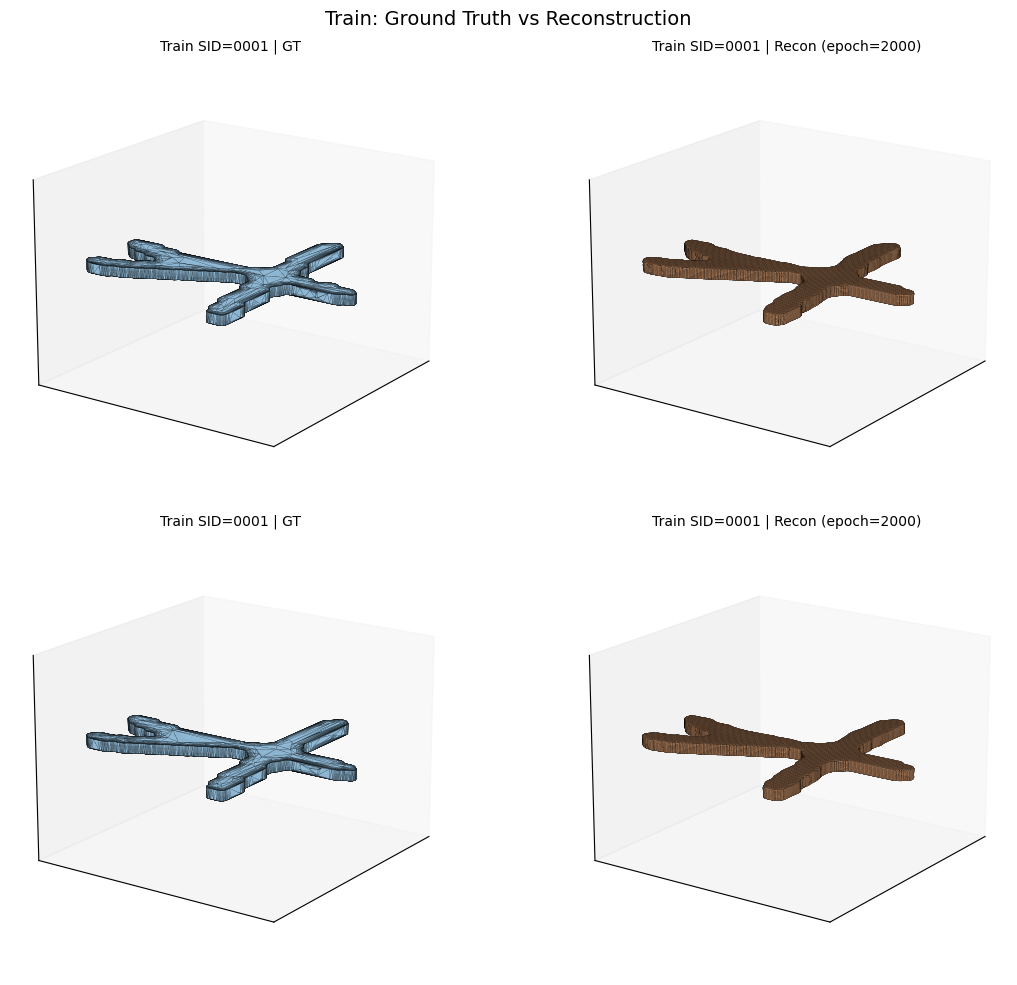

In [56]:
# Two train starmen: GT vs recon
fig = plt.figure(figsize=(12, 10))
for i, b in enumerate(train_ids):
    sid = short_sid(b)
    gt_p = gt_mesh_path(b)
    recon_p = latest_epoch_ply(TRAIN_RECON_ROOT, b)

    gt_m = load_trimesh(gt_p)
    recon_m = load_trimesh(recon_p)

    ax_l = fig.add_subplot(2, 2, i * 2 + 1, projection="3d")
    draw_mesh(ax_l, gt_m, f"Train SID={sid} | GT")

    ax_r = fig.add_subplot(2, 2, i * 2 + 2, projection="3d")
    draw_mesh(ax_r, recon_m, f"Train SID={sid} | Recon ({recon_p.stem})", color="#f2b07f")

plt.suptitle("Train: Ground Truth vs Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()


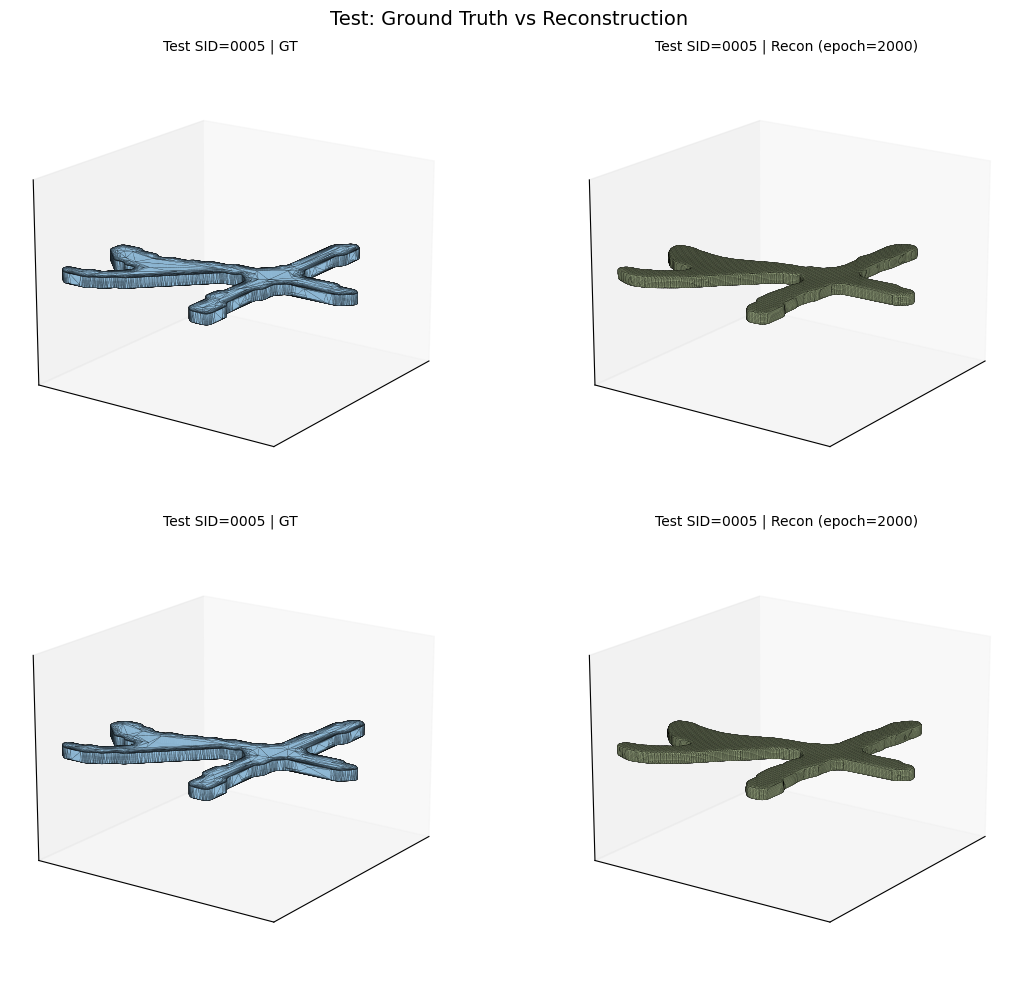

In [57]:
# Two test starmen: GT vs recon (auto-reconstructed if missing)
fig = plt.figure(figsize=(12, 10))
for i, b in enumerate(test_ids):
    sid = short_sid(b)
    gt_p = gt_mesh_path(b)
    recon_p = test_recon_paths[b]

    gt_m = load_trimesh(gt_p)
    recon_m = load_trimesh(recon_p)

    ax_l = fig.add_subplot(2, 2, i * 2 + 1, projection="3d")
    draw_mesh(ax_l, gt_m, f"Test SID={sid} | GT")

    ax_r = fig.add_subplot(2, 2, i * 2 + 2, projection="3d")
    draw_mesh(ax_r, recon_m, f"Test SID={sid} | Recon ({recon_p.stem})", color="#c7d9a8")

plt.suptitle("Test: Ground Truth vs Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()


In [58]:
print("Train selections:")
for b in train_ids:
    print("-", b)
    print("   GT   :", gt_mesh_path(b))
    print("   Recon:", latest_epoch_ply(TRAIN_RECON_ROOT, b))

print("\nTest selections:")
for b in test_ids:
    print("-", b)
    print("   GT   :", gt_mesh_path(b))
    print("   Recon:", test_recon_paths[b])


Train selections:
- starman3d__ds-output_random_noacc__sid-0001__tp-00__age-m006p55__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_0
   GT   : /home/jakaria/starmen/starman_all_meshes/subsets/first_100_ids_10_scans/meshes/output_random_noacc/mesh_minimal_scaled_obj_files/starman3d__ds-output_random_noacc__sid-0001__tp-00__age-m006p55__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_0.obj
   Recon: /home/jakaria/INR/Deep3DComp/examples/Starmen_subset_100_id/minimal_eikonal/TensorBoard/ReconstructionsTrain/starman3d__ds-output_random_noacc__sid-0001__tp-00__age-m006p55__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_0/epoch=2000.ply
- starman3d__ds-output_random_noacc__sid-0001__tp-01__age-m005p56__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_1
   GT   : /home/jakaria/starmen/starman_all_meshes/subsets/first_100_ids_10_scans/meshes/output_random_noacc/mesh_minimal_scaled_obj_files/starman3d__ds-output_random_noacc__sid-0001__tp-01__ag

## Reconstruct All Test Shapes For One Subject ID

Set `TARGET_TEST_SUBJECT_ID` below. The cell reconstructs all matching test shapes (if missing).

In [59]:
# Reconstruct all test shapes for one subject ID (SID).
# Example: 5 -> "0005"
TARGET_TEST_SUBJECT_ID = 5
sid_token = str(TARGET_TEST_SUBJECT_ID).zfill(4)

subject_test_ids = []
for n in test_split:
    b = base_id(n)
    if f"__sid-{sid_token}__" in b and gt_mesh_path(b).exists() and sdf_npz_path(b).exists():
        subject_test_ids.append(b)

subject_test_ids = sorted(subject_test_ids)
if not subject_test_ids:
    raise RuntimeError(f"No test shapes found for SID={sid_token}")

print(f"SID={sid_token}: {len(subject_test_ids)} test shapes")

subject_test_recon_paths = {}
for b in subject_test_ids:
    recon_ply, created = reconstruct_and_save_if_missing(
        b,
        TEST_RECON_ROOT,
        decoder,
        MODEL_EPOCH,
        num_iterations=RECON_ITERS,
        num_samples=RECON_NUM_SAMPLES,
        lr=RECON_LR,
        clamp_dist=CLAMP_DIST,
        grid_res=RECON_GRID_RES,
        force_reconstruct=FORCE_RECON,
        num_restarts=RECON_RESTARTS,
        code_reg_lambda=RECON_CODE_REG_LAMBDA,
        code_reg_type=RECON_CODE_REG_TYPE,
        code_bound=RECON_CODE_BOUND,
        use_train_prior=RECON_USE_TRAIN_PRIOR,
        dist_weight=RECON_DIST_WEIGHT,
        keep_largest=KEEP_LARGEST_COMPONENT,
        refine_iterations=RECON_REFINE_ITERS,
        refine_lr=RECON_REFINE_LR,
        auto_iso_level=RECON_AUTO_ISO_LEVEL,
        iso_candidates=RECON_ISO_CANDIDATES,
        iso_holdout_samples=RECON_ISO_HOLDOUT_SAMPLES,
        smooth_sigma=RECON_SMOOTH_SIGMA,
        use_train_latent_seeds=RECON_USE_TRAIN_LATENT_SEEDS,
        surface_weight=RECON_SURFACE_WEIGHT,
        surface_band=RECON_SURFACE_BAND,
        eikonal_weight=RECON_EIKONAL_WEIGHT,
        eikonal_points=RECON_EIKONAL_POINTS,
    )
    subject_test_recon_paths[b] = recon_ply
    meta_path = recon_ply.with_suffix(".pth")
    if meta_path.exists():
        meta = torch.load(meta_path, map_location="cpu")
        print(f"  {b} -> {recon_ply.name} (created={created}, final={meta.get('final_loss'):.6f}, iso={meta.get('iso_level')})")
    else:
        print(f"  {b} -> {recon_ply.name} (created={created}, no_meta)")


SID=0005: 10 test shapes


  starman3d__ds-output_random_noacc__sid-0005__tp-00__age-m003p97__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_0 -> epoch=2000.ply (created=True, final=0.006075, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0005__tp-01__age-m002p91__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_1 -> epoch=2000.ply (created=True, final=0.005844, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0005__tp-02__age-m001p84__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_2 -> epoch=2000.ply (created=True, final=0.005786, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0005__tp-03__age-m000p77__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_3 -> epoch=2000.ply (created=True, final=0.005867, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0005__tp-04__age-p000p30__scan-SimulatedData__Reconstruction__starman__subject_s5__tp_4 -> epoch=2000.ply (created=True, final=0.005861, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0005__tp-05__age-p001p36

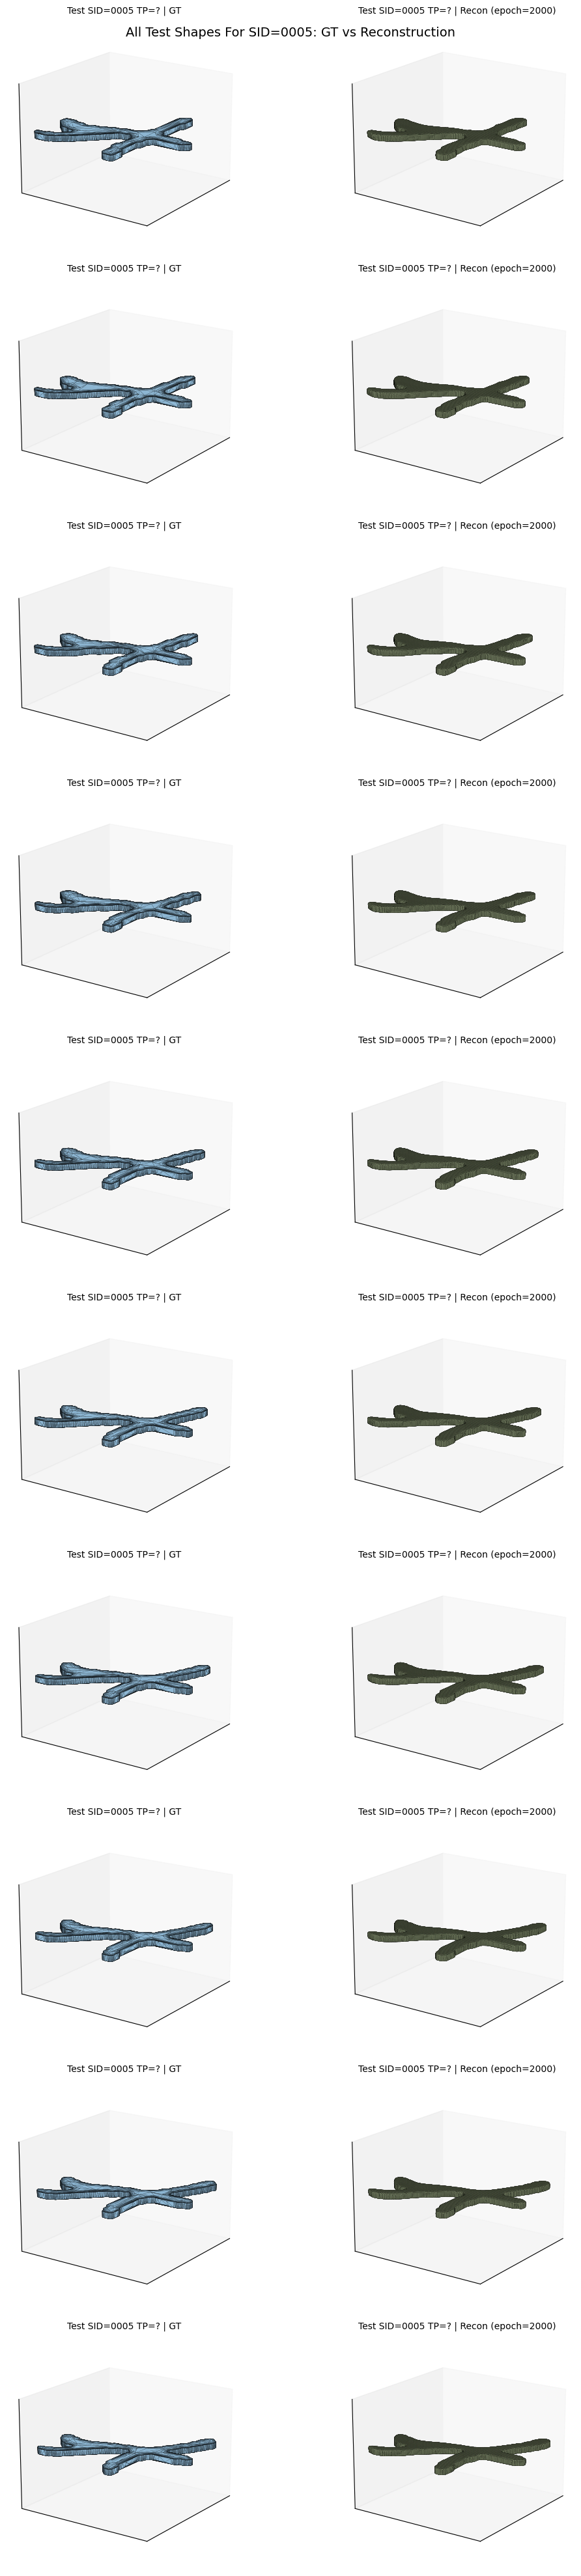

In [60]:
# Side-by-side GT vs reconstructed for all shapes of the selected test SID.
if "subject_test_ids" not in globals() or "subject_test_recon_paths" not in globals():
    raise RuntimeError("Run the previous cell first.")

n = len(subject_test_ids)
fig = plt.figure(figsize=(12, max(4, 4 * n)))

for i, b in enumerate(subject_test_ids):
    sid = short_sid(b)
    m_tp = re.search(r"__tp-(\\d+)", b)
    tp = m_tp.group(1) if m_tp else "?"

    gt_p = gt_mesh_path(b)
    recon_p = subject_test_recon_paths[b]

    gt_m = load_trimesh(gt_p)
    recon_m = load_trimesh(recon_p)

    ax_l = fig.add_subplot(n, 2, 2 * i + 1, projection="3d")
    draw_mesh(ax_l, gt_m, f"Test SID={sid} TP={tp} | GT")

    ax_r = fig.add_subplot(n, 2, 2 * i + 2, projection="3d")
    draw_mesh(ax_r, recon_m, f"Test SID={sid} TP={tp} | Recon ({recon_p.stem})", color="#c7d9a8")

plt.suptitle(f"All Test Shapes For SID={sid_token}: GT vs Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()

## Reconstruct All Train Shapes For One Subject ID

Set `TARGET_TRAIN_SUBJECT_ID` below. The cell reconstructs all matching train shapes (if missing or forced).


In [61]:
# Reconstruct all train shapes for one subject ID (SID).
# Example: 1 -> "0001"
TARGET_TRAIN_SUBJECT_ID = 1
sid_token_train = str(TARGET_TRAIN_SUBJECT_ID).zfill(4)

train_subject_ids = []
for n in train_split:
    b = base_id(n)
    if f"__sid-{sid_token_train}__" in b and gt_mesh_path(b).exists() and sdf_npz_path(b).exists():
        train_subject_ids.append(b)

train_subject_ids = sorted(train_subject_ids)
if not train_subject_ids:
    raise RuntimeError(f"No train shapes found for SID={sid_token_train}")

print(f"Train SID={sid_token_train}: {len(train_subject_ids)} shapes")

train_subject_recon_paths = {}
for b in train_subject_ids:
    recon_ply, created = reconstruct_and_save_if_missing(
        b,
        TRAIN_RECON_ROOT,
        decoder,
        MODEL_EPOCH,
        num_iterations=RECON_ITERS,
        num_samples=RECON_NUM_SAMPLES,
        lr=RECON_LR,
        clamp_dist=CLAMP_DIST,
        grid_res=RECON_GRID_RES,
        force_reconstruct=FORCE_RECON,
        num_restarts=RECON_RESTARTS,
        code_reg_lambda=RECON_CODE_REG_LAMBDA,
        code_reg_type=RECON_CODE_REG_TYPE,
        code_bound=RECON_CODE_BOUND,
        use_train_prior=RECON_USE_TRAIN_PRIOR,
        dist_weight=RECON_DIST_WEIGHT,
        keep_largest=KEEP_LARGEST_COMPONENT,
        refine_iterations=RECON_REFINE_ITERS,
        refine_lr=RECON_REFINE_LR,
        auto_iso_level=RECON_AUTO_ISO_LEVEL,
        iso_candidates=RECON_ISO_CANDIDATES,
        iso_holdout_samples=RECON_ISO_HOLDOUT_SAMPLES,
        smooth_sigma=RECON_SMOOTH_SIGMA,
        use_train_latent_seeds=RECON_USE_TRAIN_LATENT_SEEDS,
        surface_weight=RECON_SURFACE_WEIGHT,
        surface_band=RECON_SURFACE_BAND,
        eikonal_weight=RECON_EIKONAL_WEIGHT,
        eikonal_points=RECON_EIKONAL_POINTS,
    )
    train_subject_recon_paths[b] = recon_ply
    meta_path = recon_ply.with_suffix(".pth")
    if meta_path.exists():
        meta = torch.load(meta_path, map_location="cpu")
        print(f"  {b} -> {recon_ply.name} (created={created}, final={meta.get('final_loss'):.6f}, iso={meta.get('iso_level')})")
    else:
        print(f"  {b} -> {recon_ply.name} (created={created}, no_meta)")


Train SID=0001: 10 shapes


  starman3d__ds-output_random_noacc__sid-0001__tp-00__age-m006p55__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_0 -> epoch=2000.ply (created=True, final=0.003710, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0001__tp-01__age-m005p56__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_1 -> epoch=2000.ply (created=True, final=0.003260, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0001__tp-02__age-m004p57__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_2 -> epoch=2000.ply (created=True, final=0.003033, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0001__tp-03__age-m003p58__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_3 -> epoch=2000.ply (created=True, final=0.003283, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0001__tp-04__age-m002p60__scan-SimulatedData__Reconstruction__starman__subject_s1__tp_4 -> epoch=2000.ply (created=True, final=0.002957, iso=0.0)
  starman3d__ds-output_random_noacc__sid-0001__tp-05__age-m001p61

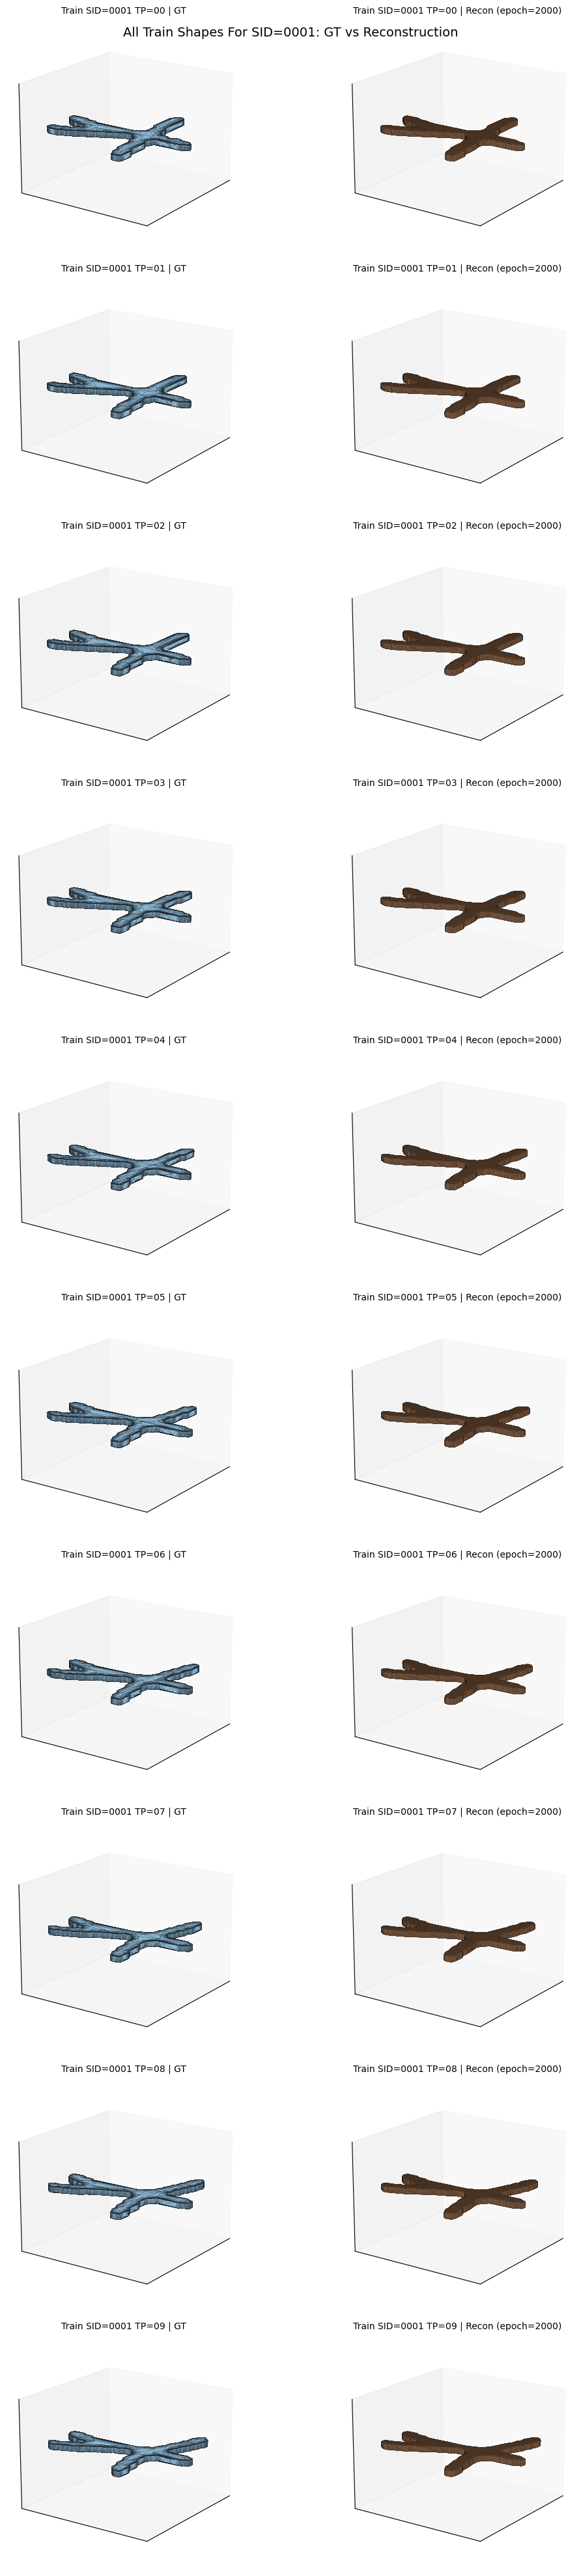

In [62]:
# Side-by-side GT vs reconstructed for all shapes of the selected train SID.
if "train_subject_ids" not in globals() or "train_subject_recon_paths" not in globals():
    raise RuntimeError("Run the previous train reconstruction cell first.")

n = len(train_subject_ids)
fig = plt.figure(figsize=(12, max(4, 4 * n)))

for i, b in enumerate(train_subject_ids):
    sid = short_sid(b)
    m_tp = re.search(r"__tp-(\d+)", b)
    tp = m_tp.group(1) if m_tp else "?"

    gt_p = gt_mesh_path(b)
    recon_p = train_subject_recon_paths[b]

    gt_m = load_trimesh(gt_p)
    recon_m = load_trimesh(recon_p)

    ax_l = fig.add_subplot(n, 2, 2 * i + 1, projection="3d")
    draw_mesh(ax_l, gt_m, f"Train SID={sid} TP={tp} | GT")

    ax_r = fig.add_subplot(n, 2, 2 * i + 2, projection="3d")
    draw_mesh(ax_r, recon_m, f"Train SID={sid} TP={tp} | Recon ({recon_p.stem})", color="#f2b07f")

plt.suptitle(f"All Train Shapes For SID={sid_token_train}: GT vs Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()
